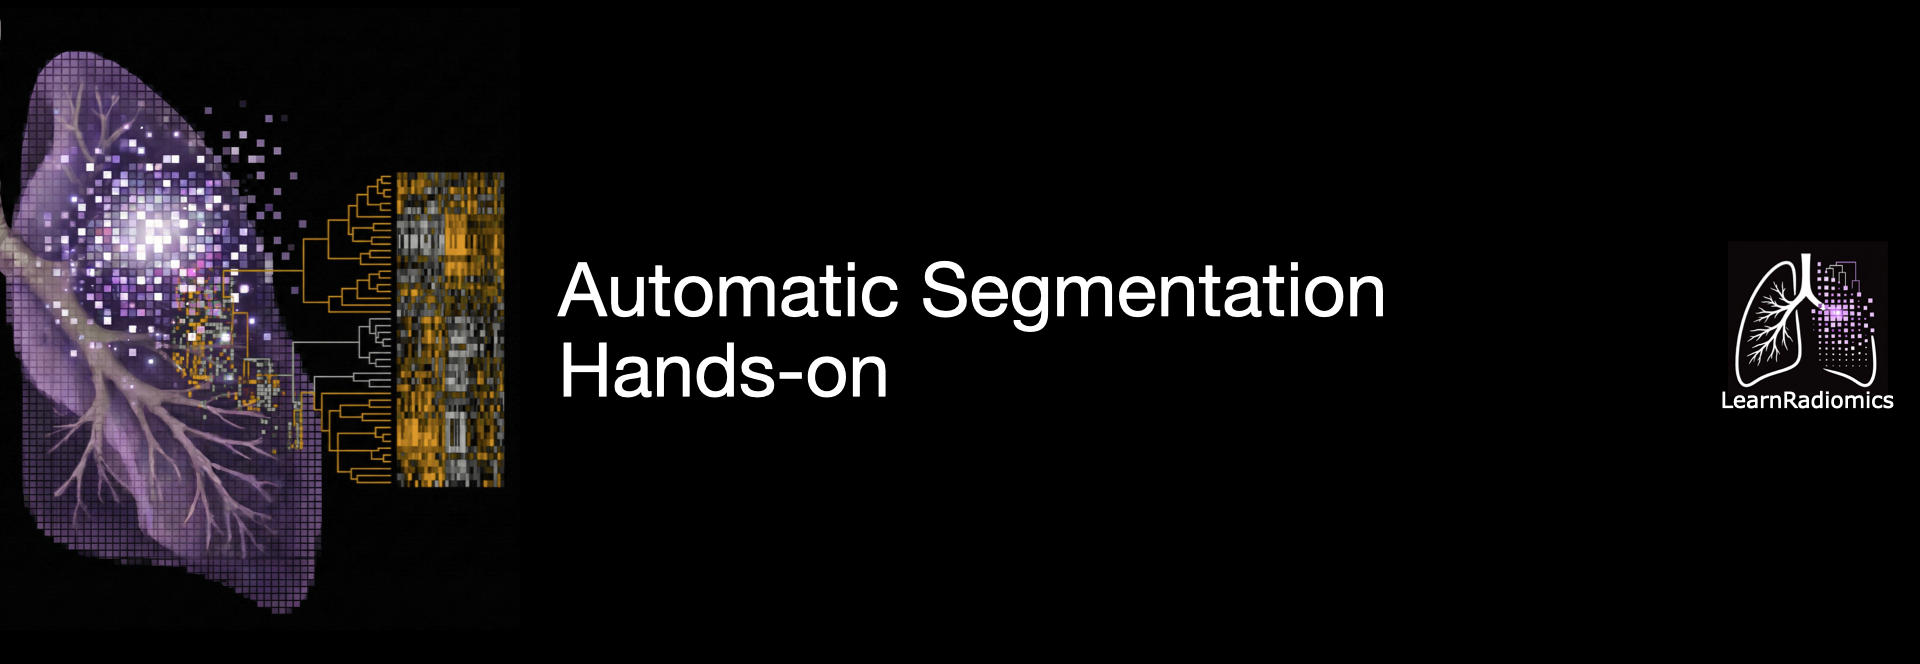

In [ ]:
! pip install SimpleITK
! pip install TotalSegmentator

In [ ]:
## load libraries
import numpy as np
import SimpleITK as sitk
import requests
import json
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import plotly.graph_objects as go

from skimage.measure import label, regionprops
from totalsegmentator.python_api import totalsegmentator

## Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Download Kaggle token that allows access to the dataset
json_response = requests.get("https://raw.github.com/learnradiomics/Image_processing/main/kaggle.json")
token = json.loads(json_response.text)

with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Load data from Kaggle
! pip install kaggle
! mkdir ~/.kaggle
! mkdir 'segmentations'
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download hshenriquez/learnradiomics-image-segmentation
!unzip /content/learnradiomics-image-segmentation


In [ ]:
## Visualization functions and segmentation volume calculation:
def visualize_3d_mask_labels_sampled(mask, sample_frac=0.1, alpha=0.5, title=""):
    zs, ys, xs = np.where(mask > 0)
    vals = mask[zs, ys, xs]
    # sampling
    n = len(zs)
    idx = np.random.choice(n, size=int(n * sample_frac), replace=False)
    zs, ys, xs, vals = zs[idx], ys[idx], xs[idx], vals[idx]

    fig = go.Figure()
    for lbl in np.unique(vals):
        sel = vals == lbl
        fig.add_trace(go.Scatter3d(
            x=xs[sel], y=ys[sel], z=zs[sel],
            mode='markers',
            name=f"Label {lbl}",
            marker=dict(size=2, opacity=alpha)
        ))
    fig.update_layout(title=title,
                      scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
    fig.show()

def calculate_volume(mask_array, volume_itk):
    spacing = volume_itk.GetSpacing()
    voxel_vol = spacing[0] * spacing[1] * spacing[2]
    vol_cc = (mask_array.sum() * voxel_vol) / 1000
    return vol_cc


In [ ]:
## Image and segmentation output directories:
image_path = "/content/torax3d_image.nii"
output_path = '/content/segmentations'


In [ ]:
## Load the image from image_path as an ITK object
volume = sitk.ReadImage(image_path)
volume_array = sitk.GetArrayFromImage(volume)  ## convert to array

print(f"Volume dimensions: {volume_array.shape}")


In [ ]:
%matplotlib inline

## Visualization of an axial slice
axial_slice = 310

plt.figure()
plt.imshow(volume_array[axial_slice, :, :], cmap='gray')
plt.show()


## TotalSegmentator v2

* https://github.com/wasserth/TotalSegmentator

* reference: https://pubs.rsna.org/doi/10.1148/ryai.230024


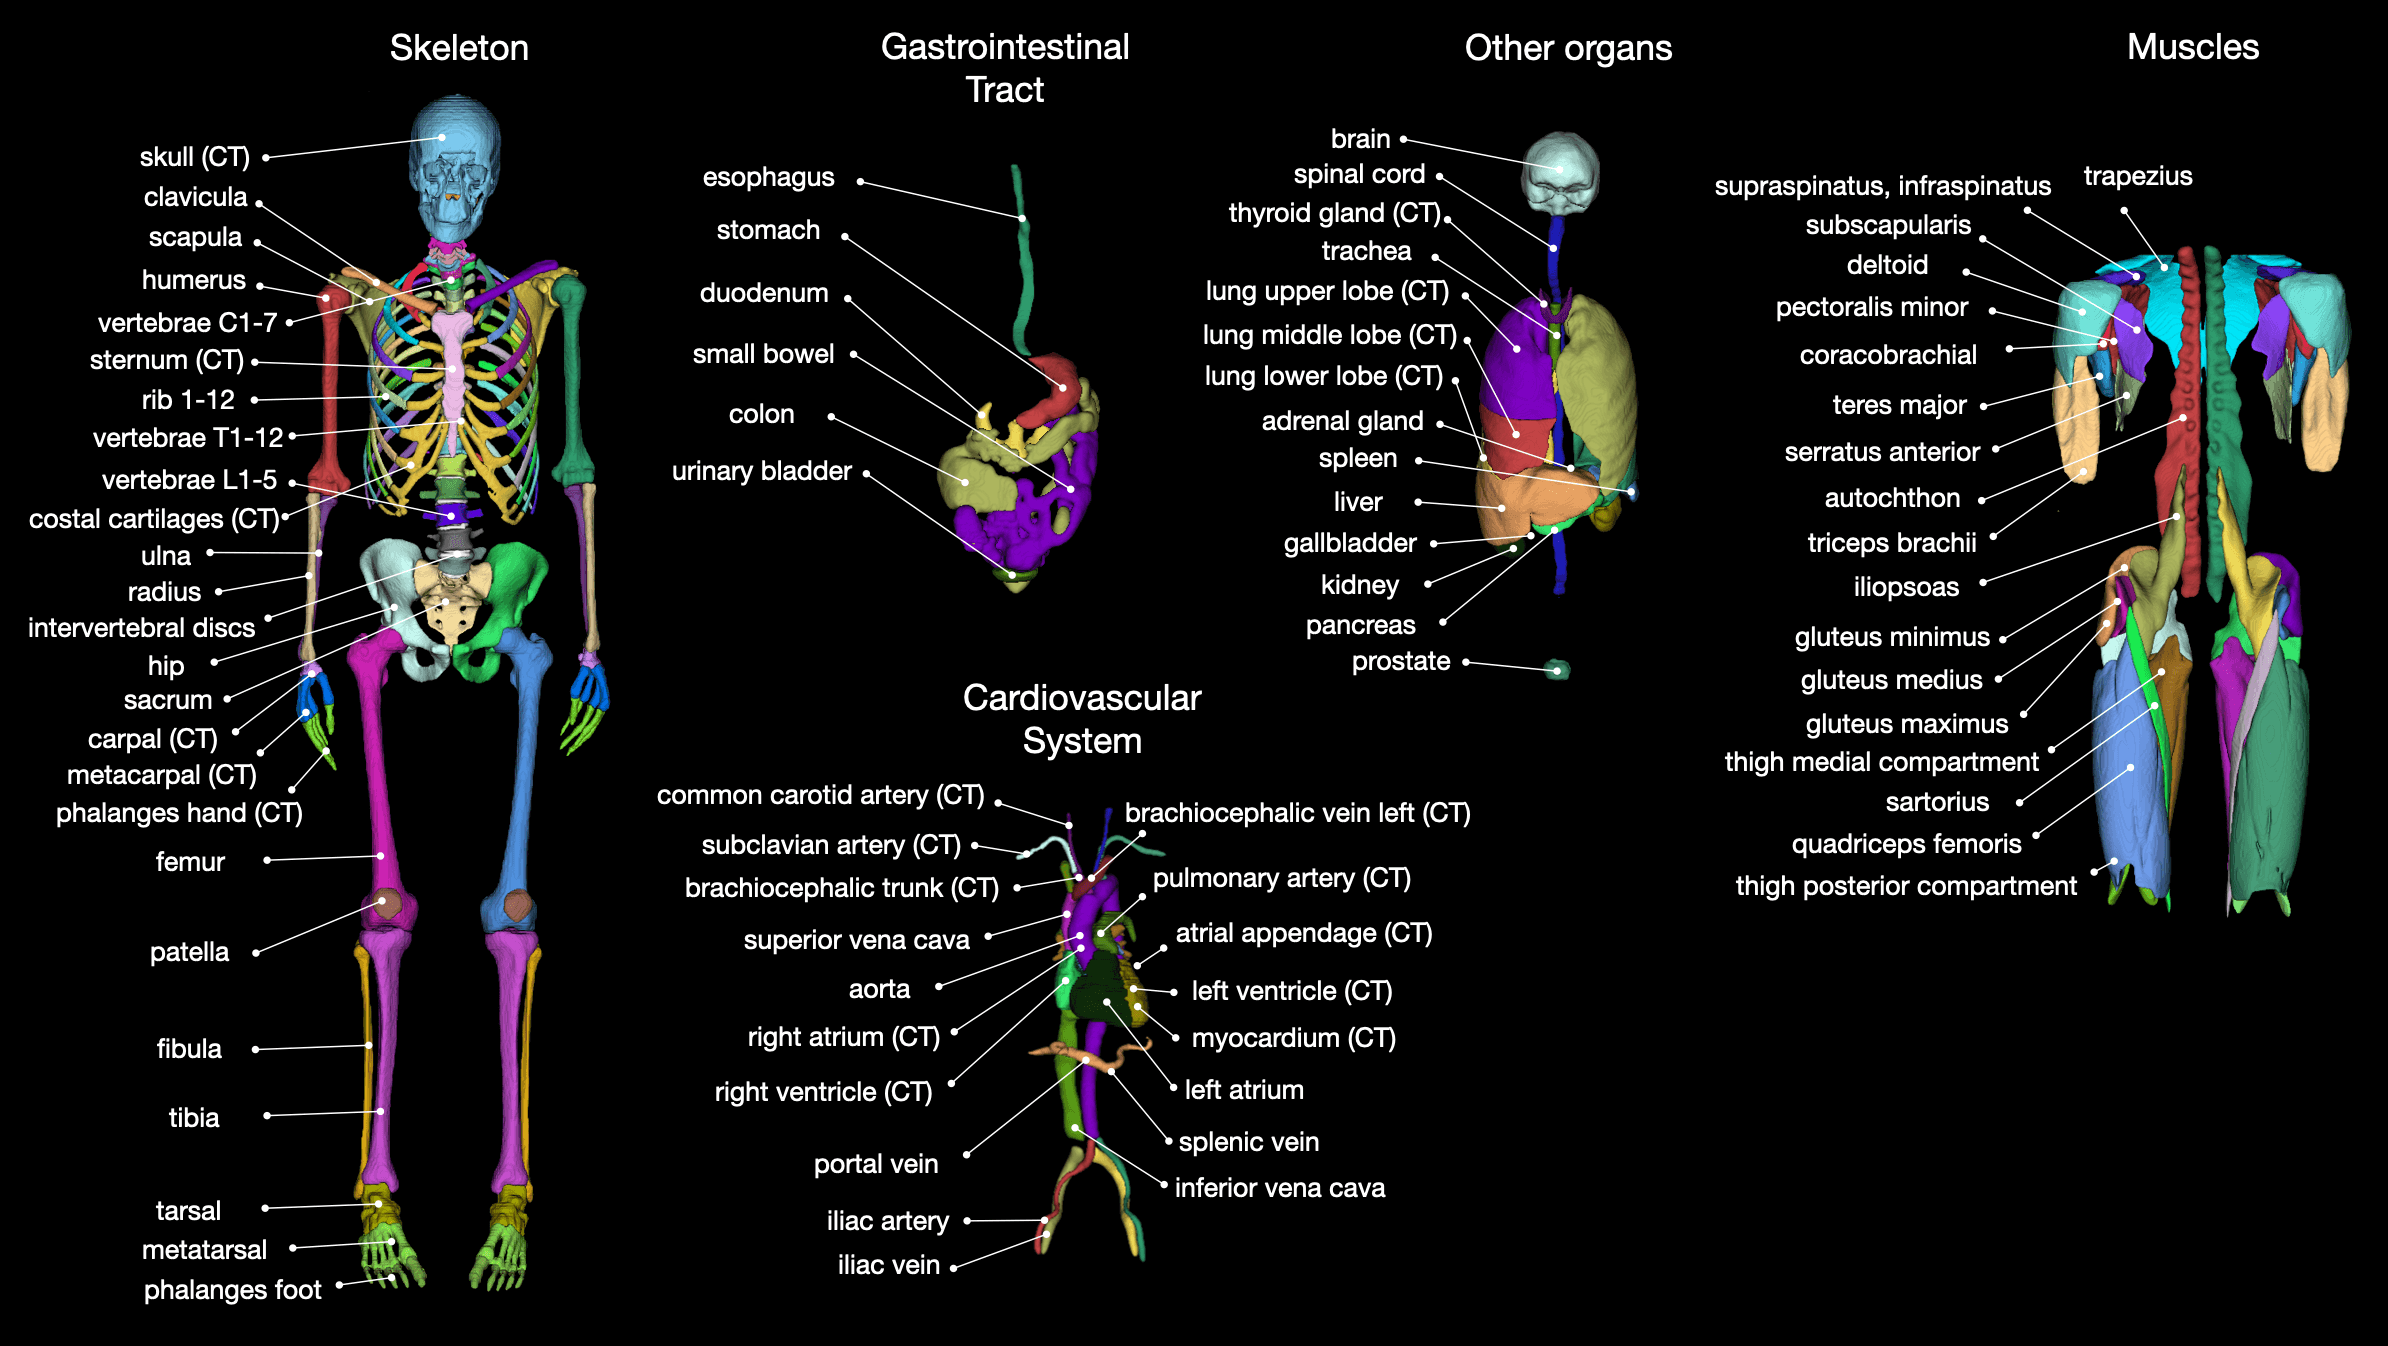

In [ ]:
### Run TotalSegmentator
### roi_subset: defines the structures to segment.

## Complete segmentation of all structures
#totalsegmentator(image_path, output_path, task='total')

### Targeted selection: roi_subset
totalsegmentator(image_path, output_path, roi_subset=['lung_upper_lobe_right', 'lung_upper_lobe_left', 'lung_middle_lobe_right',
                                                        'lung_lower_lobe_left', 'lung_lower_lobe_right'])
## add more structures: task
totalsegmentator(image_path, output_path, task='lung_nodules')
#totalsegmentator(image_path, output_path, task='lung_vessels')


In [ ]:
### Combine masks
labels = [name[:-7] for name in os.listdir(output_path)]
print("combining...", labels)

masks_dict = {}

for name in labels:
  try:
    path = f"/content/segmentations/{name}.nii.gz"
    image = sitk.ReadImage(path)
    masks_dict[name] = image
  except:
    continue

arrays_dict = {}

for name in masks_dict.keys():
  array_name = name + '_array'
  array = sitk.GetArrayFromImage(masks_dict[name])
  arrays_dict[array_name] = array

  combined = np.zeros_like(arrays_dict[list(arrays_dict.keys())[0]], dtype=np.uint8)

for i in range(len(list(arrays_dict.keys())[1:])):
  combined = np.where(arrays_dict[list(arrays_dict.keys())[i + 1]], i + 2, combined)

combined = np.where(arrays_dict[list(arrays_dict.keys())[0]], 1, combined)

label_img = sitk.GetImageFromArray(combined)
label_img.SetOrigin(masks_dict[list(masks_dict.keys())[0]].GetOrigin())
label_img.SetSpacing(masks_dict[list(masks_dict.keys())[0]].GetSpacing())
label_img.SetDirection(masks_dict[list(masks_dict.keys())[0]].GetDirection())

sitk.WriteImage(label_img, "/content/combined_segmentation.nii.gz")


In [ ]:
visualize_3d_mask_labels_sampled(combined, sample_frac=0.05, alpha=0.5, title="Segmentation")
